What are the most demanded skills for the top 3 most popular data roles?

Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill perscantager
4. Plot final findings

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_Ger = df[df['job_country'] == 'Germany']

In [3]:
df_skills = df_Ger.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
907,python,Data Scientist,4157
906,python,Data Engineer,3524
1139,sql,Data Engineer,3145
1138,sql,Data Analyst,2947
905,python,Data Analyst,2309
...,...,...,...
254,django,Business Analyst,1
255,django,Cloud Engineer,1
256,django,Data Analyst,1
1127,spring,Senior Data Scientist,1


In [4]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

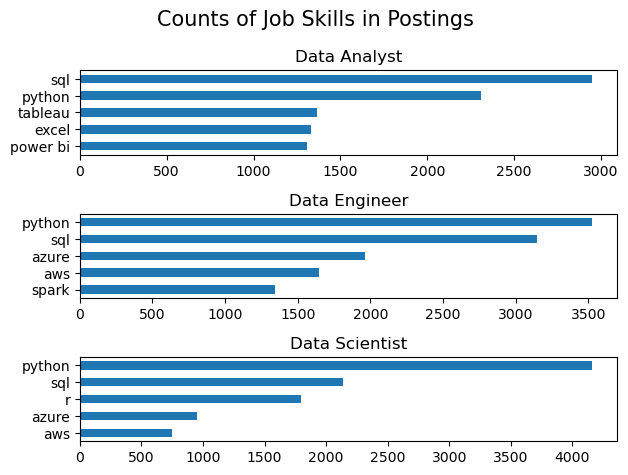

In [22]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh',x = 'job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].invert_yaxis()
fig.suptitle("Counts of Job Skills in Postings", fontsize=15)
fig.tight_layout()

    

In [25]:
df_job_title_count = df_Ger['job_title_short'].value_counts().reset_index(name='jobs_total')

In [29]:
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skill_perc['skill_perc'] = df_skill_perc['skill_count'] / df_skill_perc['jobs_total'] * 100
df_skill_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_perc
0,python,Data Scientist,4157,6745,61.630838
1,python,Data Engineer,3524,6675,52.794007
2,sql,Data Engineer,3145,6675,47.116105
3,sql,Data Analyst,2947,7131,41.326602
4,python,Data Analyst,2309,7131,32.379750
...,...,...,...,...,...
1377,django,Business Analyst,1,817,0.122399
1378,django,Cloud Engineer,1,189,0.529101
1379,django,Data Analyst,1,7131,0.014023
1380,spring,Senior Data Scientist,1,1737,0.057571


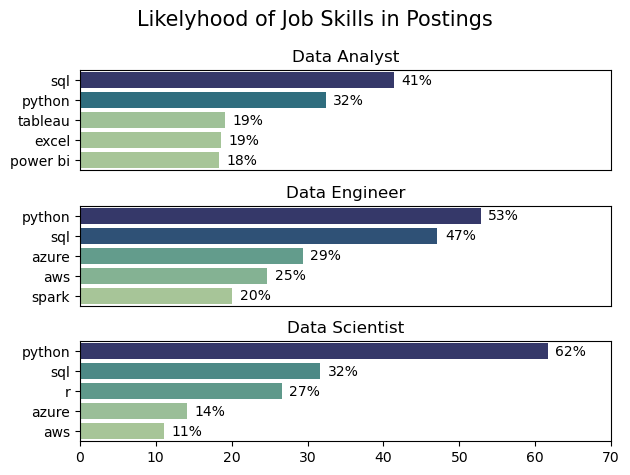

In [47]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head()
    sns.barplot(data=df_plot, x='skill_perc',  y='job_skills', ax=ax[i], hue='skill_count', palette='crest')
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,70)
    ax[i].set_title(job_title)
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+1, j, f'{v:.0f}%', va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])


fig.suptitle("Likelyhood of Job Skills in Postings", fontsize=15)
fig.tight_layout()

    